<a href="https://www.kaggle.com/code/aelhajj/march-ml-mania-2026-tabicl?scriptVersionId=303273937" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# March Machine Learning Mania 2026

Predict NCAA tournament outcomes (men's + women's) using an ensemble of XGBoost, LightGBM, AdaBoost, and TabICL v2.

TabFPN v2 was tried at first, but TabICL v2 was kept because it performs better.

- **Metric**: Brier score (MSE for binary outcomes)
- **Target**: P(lower TeamID beats higher TeamID)

## 1. Setup

In [1]:
import sys
sys.path.append("/kaggle/usr/lib/notebooks/aelhajj/utils_py")
sys.path.append("/kaggle/usr/lib/notebooks/aelhajj/theme_py")

In [2]:
%pip install catppuccin[matplotlib] --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install tabicl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.5/206.5 kB 5.0 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from theme_py import apply
from utils_py import (
    load_data, compute_elo, compute_elo_trajectory_stats, compute_season_stats, compute_massey_features,
    build_seed_map, build_training_data, build_features_vectorized, parse_seed,
    train_or_load, brier_score, leave_one_season_out_cv, leave_one_season_out_cv_gendered,
    compute_sample_weights,
    generate_submission, generate_submission_gendered,
    compute_sos, compute_momentum, compute_conference_strength, compute_coach_experience,
    compute_seed_matchup_prior, compute_conf_tourney_champion, compute_conf_tourney_wins,
    compute_close_game_win_rate,
    plot_brier_by_season, plot_feature_importance,
    plot_prediction_distribution, plot_calibration_curve,
    plot_model_comparison,
)

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tabicl import TabICLClassifier

warnings.filterwarnings("ignore")
C = apply("mocha")
RANDOM_STATE = 42

## 2. Data Loading

In [6]:
data = load_data(Path("/kaggle/input/competitions/march-machine-learning-mania-2026"))
#data = load_data()
for name, df in data.items():
    print(f"{name:25s} {str(df.shape):>15s}")

m_teams                          (381, 4)
w_teams                          (379, 2)
m_regular                     (198079, 8)
w_regular                     (142093, 8)
m_regular_detail             (124031, 34)
w_regular_detail              (86773, 34)
m_tourney                       (2585, 8)
w_tourney                       (1717, 8)
m_tourney_detail               (1449, 34)
w_tourney_detail                (961, 34)
m_seeds                         (2626, 3)
w_seeds                         (1744, 3)
m_massey                     (5819228, 5)
m_conferences                  (13753, 3)
w_conferences                   (9853, 3)
m_coaches                      (13900, 5)
m_conf_tourney                  (6793, 5)
w_conf_tourney                  (6481, 5)
sample_sub                    (519144, 2)
sample_sub2                   (132133, 2)


In [7]:
data["m_regular_detail"].head(3)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23


In [8]:
# Submission structure
print("Stage 1:", data["sample_sub"].shape)
print(data["sample_sub"].head())
print()
print("Stage 2:", data["sample_sub2"].shape)
print(data["sample_sub2"].head())

Stage 1: (519144, 2)
               ID  Pred
0  2022_1101_1102   0.5
1  2022_1101_1103   0.5
2  2022_1101_1104   0.5
3  2022_1101_1105   0.5
4  2022_1101_1106   0.5

Stage 2: (132133, 2)
               ID  Pred
0  2026_1101_1102   0.5
1  2026_1101_1103   0.5
2  2026_1101_1104   0.5
3  2026_1101_1105   0.5
4  2026_1101_1106   0.5


## 3. EDA

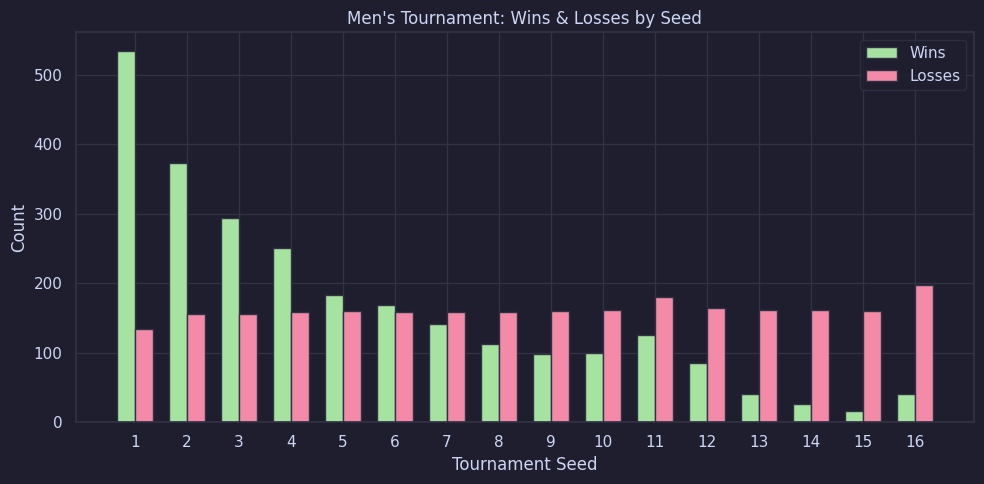

In [9]:
# Seed vs tournament wins (men's)
m_seeds = data["m_seeds"].copy()
m_seeds["SeedNum"] = m_seeds["Seed"].apply(parse_seed)
m_tourney = data["m_tourney"]

# Count wins by seed
w_seeds = m_tourney.merge(m_seeds, left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
seed_wins = w_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

l_seeds = m_tourney.merge(m_seeds, left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
seed_losses = l_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 17)
w = 0.35
ax.bar(x - w/2, seed_wins.values, w, label="Wins", color=C.green)
ax.bar(x + w/2, seed_losses.values, w, label="Losses", color=C.red)
ax.set_xlabel("Tournament Seed")
ax.set_ylabel("Count")
ax.set_title("Men's Tournament: Wins & Losses by Seed")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

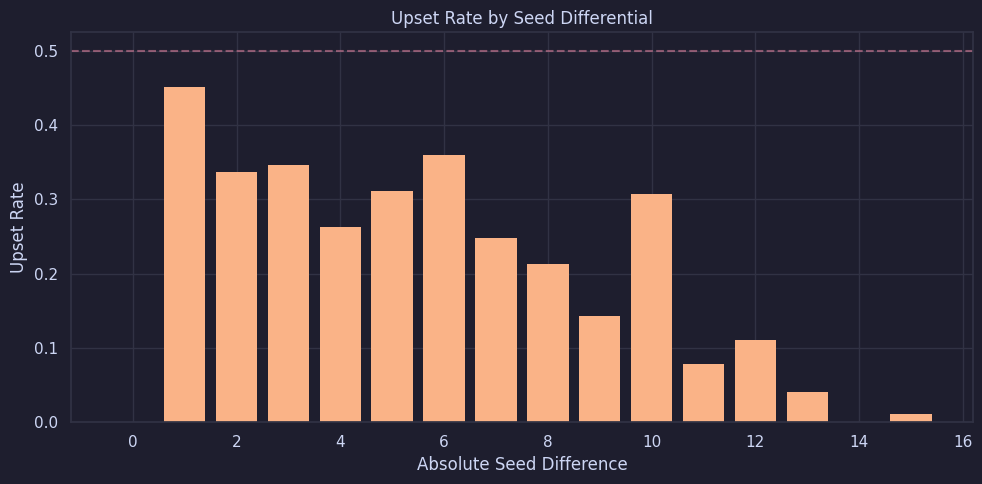

In [10]:
# Upset frequency: how often does the higher seed (worse number) win?
tourney_all = pd.concat([data["m_tourney"], data["w_tourney"]], ignore_index=True)
all_seeds = pd.concat([data["m_seeds"], data["w_seeds"]], ignore_index=True)
all_seeds["SeedNum"] = all_seeds["Seed"].apply(parse_seed)
seed_lookup = dict(zip(zip(all_seeds["Season"], all_seeds["TeamID"]), all_seeds["SeedNum"]))

upsets = []
for _, row in tourney_all.iterrows():
    ws = seed_lookup.get((row["Season"], row["WTeamID"]))
    ls = seed_lookup.get((row["Season"], row["LTeamID"]))
    if ws is not None and ls is not None:
        diff = abs(ws - ls)
        upset = ws > ls  # winner had a worse (higher) seed number
        upsets.append({"SeedDiff": diff, "Upset": int(upset)})

upset_df = pd.DataFrame(upsets)
upset_rate = upset_df.groupby("SeedDiff")["Upset"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(upset_rate.index, upset_rate.values, color=C.peach, edgecolor="none")
ax.axhline(0.5, color=C.red, linestyle="--", alpha=0.5)
ax.set_xlabel("Absolute Seed Difference")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate by Seed Differential")
plt.tight_layout()
plt.show()

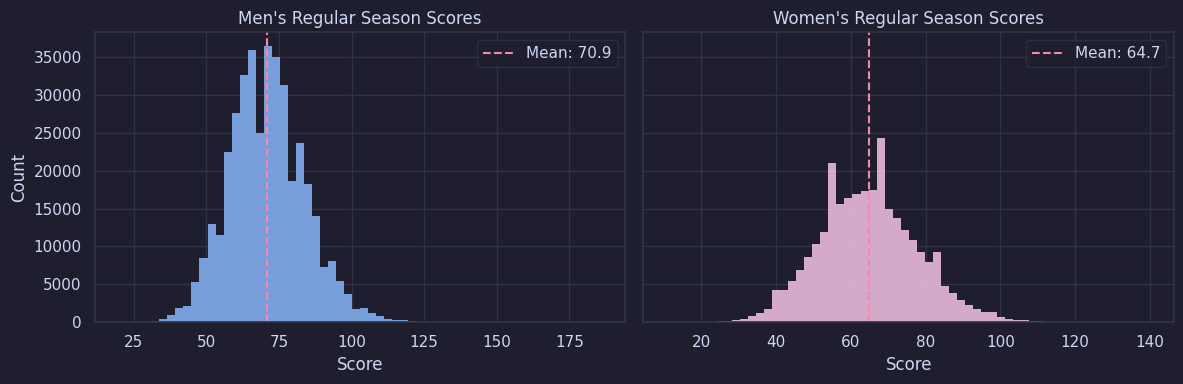

In [11]:
# Score distributions (men's vs women's regular season)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (key, title, color) in zip(axes, [
    ("m_regular", "Men's", C.blue),
    ("w_regular", "Women's", C.pink),
]):
    df = data[key]
    scores = pd.concat([df["WScore"], df["LScore"]])
    ax.hist(scores, bins=60, color=color, edgecolor="none", alpha=0.85)
    ax.set_xlabel("Score")
    ax.set_title(f"{title} Regular Season Scores")
    ax.axvline(scores.mean(), color=C.red, linestyle="--", label=f"Mean: {scores.mean():.1f}")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

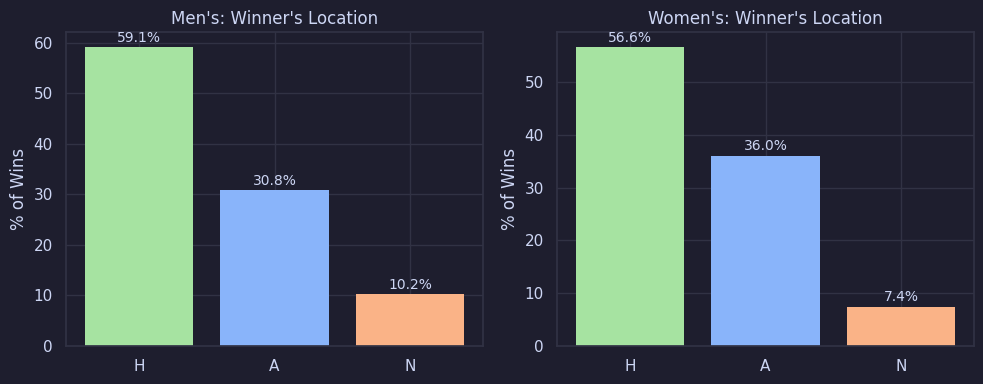

In [12]:
# Home court advantage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (key, title) in zip(axes, [("m_regular", "Men's"), ("w_regular", "Women's")]):
    df = data[key]
    loc_counts = df["WLoc"].value_counts()
    total_games = len(df)
    pcts = (loc_counts / total_games * 100)
    bars = ax.bar(pcts.index, pcts.values, color=[C.green, C.blue, C.peach][:len(pcts)], edgecolor="none")
    ax.set_ylabel("% of Wins")
    ax.set_title(f"{title}: Winner's Location")
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

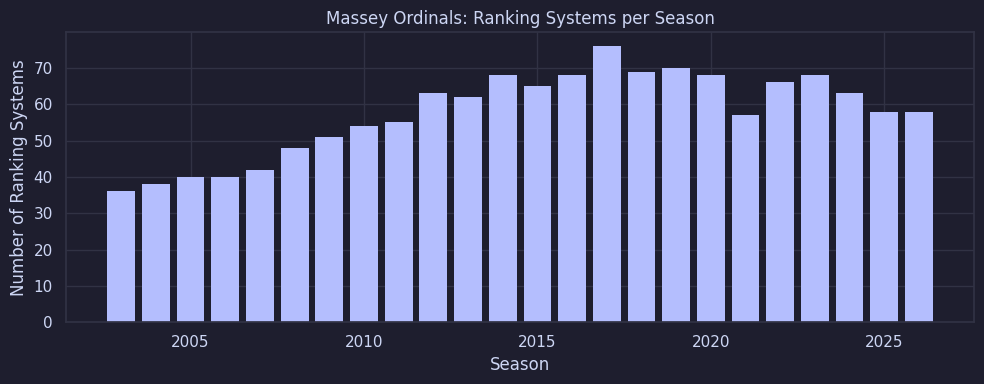

In [13]:
# Massey ordinals: systems per season
massey = data["m_massey"]
systems_per_season = massey.groupby("Season")["SystemName"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(systems_per_season.index, systems_per_season.values, color=C.lavender, edgecolor="none")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Ranking Systems")
ax.set_title("Massey Ordinals: Ranking Systems per Season")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [14]:
# Elo: previous season (end-of-season, includes tournament) -- long-term baseline
m_elo_prev = compute_elo(data["m_regular"], data["m_tourney"], include_tourney=True)
w_elo_prev = compute_elo(data["w_regular"], data["w_tourney"], include_tourney=True)
elo_prev = {**m_elo_prev, **w_elo_prev}
print(f"Previous-season Elo: {len(elo_prev):,} ratings")

Previous-season Elo: 24,158 ratings


In [15]:
# Elo: current season with margin-of-victory scaling (MOV-Elo)
# MOV-Elo scales K by log(margin+1) with autocorrelation correction -- a 30-pt blowout
# gives a bigger Elo update than a 1-pt squeaker. Proven in FiveThirtyEight's NBA model.
m_elo_curr = compute_elo(data["m_regular"], include_tourney=False, mov=True)
w_elo_curr = compute_elo(data["w_regular"], include_tourney=False, mov=True)
elo_curr = {**m_elo_curr, **w_elo_curr}
print(f"Current-season MOV-Elo: {len(elo_curr):,} ratings")

Current-season MOV-Elo: 24,158 ratings


In [16]:
# Seeds, season stats, Massey
seed_map  = build_seed_map(data["m_seeds"], data["w_seeds"])
print(f"Seed map: {len(seed_map):,} entries")

m_stats = compute_season_stats(data["m_regular_detail"])
w_stats = compute_season_stats(data["w_regular_detail"])
stats_df = pd.concat([m_stats, w_stats], ignore_index=True)
print(f"Season stats: {len(stats_df):,} team-seasons")

massey_df = compute_massey_features(data["m_massey"], day_threshold=128)
print(f"Massey features: {len(massey_df):,} team-seasons")

Seed map: 4,370 entries
Season stats: 14,311 team-seasons
Massey features: 7,980 team-seasons


In [17]:
# Sanity check: top men's teams by end-of-2025 Elo
m_teams_lut = dict(zip(data["m_teams"]["TeamID"], data["m_teams"]["TeamName"]))
top_m = sorted(
    [(m_teams_lut.get(tid, tid), r) for (s, tid), r in elo_prev.items()
     if s == 2025 and tid < 2000],
    key=lambda x: -x[1]
)[:10]
print("Top 10 men's teams by end-of-2025 Elo:")
for i, (name, elo) in enumerate(top_m, 1):
    print(f"  {i:2d}. {name}: {elo:.0f}")

Top 10 men's teams by end-of-2025 Elo:
   1. Houston: 1862
   2. Florida: 1820
   3. Duke: 1816
   4. Auburn: 1792
   5. Alabama: 1767
   6. Tennessee: 1765
   7. Drake: 1752
   8. Connecticut: 1744
   9. Michigan St: 1740
  10. St Mary's CA: 1738


In [18]:
# Elo trajectory stats: within-season trend and volatility per (Season, TeamID)
# Using MOV-Elo so trajectory captures margin-of-victory signal
m_elo_stats = compute_elo_trajectory_stats(data['m_regular'], mov=True)
w_elo_stats = compute_elo_trajectory_stats(data['w_regular'], mov=True)
elo_stats = {**m_elo_stats, **w_elo_stats}
print(f'Elo trajectory stats: {len(elo_stats):,} entries')
sample_key = next(iter(elo_stats))
print(f'Sample {sample_key}: {elo_stats[sample_key]}')

Elo trajectory stats: 23,604 entries
Sample (1985, 1228): {'EloTrend': 6.185524298654294, 'EloStd': 60.62869459854287}


In [19]:
# Strength of Schedule: mean Elo of each team's opponents
sos = compute_sos(data["m_regular"], data["w_regular"], elo_curr)
print(f"SOS: {len(sos):,} entries")

# Last-10-game momentum: win rate in final 10 regular-season games
momentum = compute_momentum(data["m_regular"], data["w_regular"], last_n=10)
print(f"Momentum: {len(momentum):,} entries")

# Conference strength: mean Elo of all teams in a team's conference
conf_strength = compute_conference_strength(data["m_conferences"], data["w_conferences"], elo_curr)
print(f"Conference strength: {len(conf_strength):,} entries")

# Coach tournament experience: cumulative NCAA tournament appearances (men only)
coach_exp = compute_coach_experience(data["m_coaches"], data["m_tourney"])
print(f"Coach experience: {len(coach_exp):,} entries (men only)")

# Seed matchup prior: historical P(better seed wins) for each seed pairing
seed_prior = compute_seed_matchup_prior(data["m_tourney"], data["w_tourney"], data["m_seeds"], data["w_seeds"])
print(f"Seed matchup prior: {len(seed_prior):,} seed pairings")

# Conference tourney champion + wins
conf_champ = compute_conf_tourney_champion(data["m_conf_tourney"], data["w_conf_tourney"])
conf_tw = compute_conf_tourney_wins(data["m_conf_tourney"], data["w_conf_tourney"])
print(f"Conf tourney champion: {sum(v == 1 for v in conf_champ.values()):,} champions across all seasons")
print(f"Conf tourney wins: {len(conf_tw):,} entries")

# Close-game win rate: win rate in games decided by ≤5 points
close_game_wr = compute_close_game_win_rate(data["m_regular"], data["w_regular"], margin_threshold=5)
print(f"Close-game win rate: {len(close_game_wr):,} entries")

SOS: 23,604 entries
Momentum: 23,604 entries
Conference strength: 23,606 entries
Coach experience: 13,398 entries (men only)
Seed matchup prior: 84 seed pairings
Conf tourney champion: 1,500 champions across all seasons
Conf tourney wins: 14,842 entries
Close-game win rate: 23,531 entries


## 5. Training Data

In [20]:
# Build training data from historical tournament results (2003+)
X, y, seasons, genders = build_training_data(
    data["m_tourney"], data["w_tourney"],
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    min_season=2003,
    elo_stats=elo_stats,
    sos=sos, momentum=momentum,
    conf_strength=conf_strength, coach_exp=coach_exp,
    seed_prior=seed_prior, conf_champ=conf_champ,
    conf_tourney_wins=conf_tw, close_game_wr=close_game_wr,
)

FEATURE_COLS = list(X.columns)

print(f"Training set: {X.shape[0]:,} games, {X.shape[1]} features")
print(f"  Men's:   {(genders == 'M').sum():,} games")
print(f"  Women's: {(genders == 'W').sum():,} games")
print(f"Seasons: {seasons.min()}–{seasons.max()}")
print(f"y balance (Team1 win rate): {y.mean():.3f}  ← should be ~0.5")
print(f"\nFeatures: {FEATURE_COLS}")
print("\nNaN counts (features with missing values):")
nan_counts = X.isna().sum()
print(nan_counts[nan_counts > 0])

Training set: 2,851 games, 29 features
  Men's:   1,449 games
  Women's: 1,402 games
Seasons: 2003–2025
y balance (Team1 win rate): 0.505  ← should be ~0.5

Features: ['EloPrevDiff', 'EloMOVDiff', 'SeedT1', 'SeedT2', 'SeedDiff', 'OffEffDiff', 'DefEffDiff', 'TempoDiff', 'ORPctDiff', 'TOPctDiff', 'FTRateDiff', 'AstRateDiff', 'ThreePtRateDiff', 'MasseyMeanDiff', 'Massey_WLKDiff', 'Massey_POMDiff', 'Massey_MORDiff', 'SOSDiff', 'MomentumDiff', 'ConfStrengthDiff', 'CoachExpDiff', 'EloTrendDiff', 'EloStdDiff', 'SeedMatchupPrior', 'ConfChampDiff', 'ConfTourneyWinsDiff', 'CloseWinRateDiff', 'SeedDiffSq', 'SeedEloDiff']

NaN counts (features with missing values):
OffEffDiff          441
DefEffDiff          441
TempoDiff           441
ORPctDiff           441
TOPctDiff           441
FTRateDiff          441
AstRateDiff         441
ThreePtRateDiff     441
MasseyMeanDiff     1402
Massey_WLKDiff     1402
Massey_POMDiff     1402
Massey_MORDiff     1402
CoachExpDiff       1402
dtype: int64


In [21]:
X.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
EloPrevDiff,2851.0,4.046,168.629,-579.517,-105.505,-0.553,118.741,614.535
EloMOVDiff,2851.0,3.320,204.072,-790.076,-115.062,-1.935,122.822,748.518
SeedT1,2851.0,6.776,4.682,1.000,3.000,6.000,11.000,16.000
SeedT2,2851.0,6.643,4.602,1.000,3.000,6.000,10.000,16.000
SeedDiff,2851.0,-0.133,7.415,-15.000,-5.000,0.000,5.000,15.000
OffEffDiff,2410.0,0.690,8.519,-31.352,-4.540,0.615,5.772,36.886
DefEffDiff,2410.0,0.238,6.932,-23.086,-4.325,0.122,4.676,34.368
TempoDiff,2410.0,0.306,4.656,-22.329,-2.598,0.347,3.329,16.890
ORPctDiff,2410.0,0.001,0.061,-0.239,-0.040,0.000,0.040,0.236
TOPctDiff,2410.0,-0.001,0.029,-0.103,-0.020,-0.001,0.018,0.104


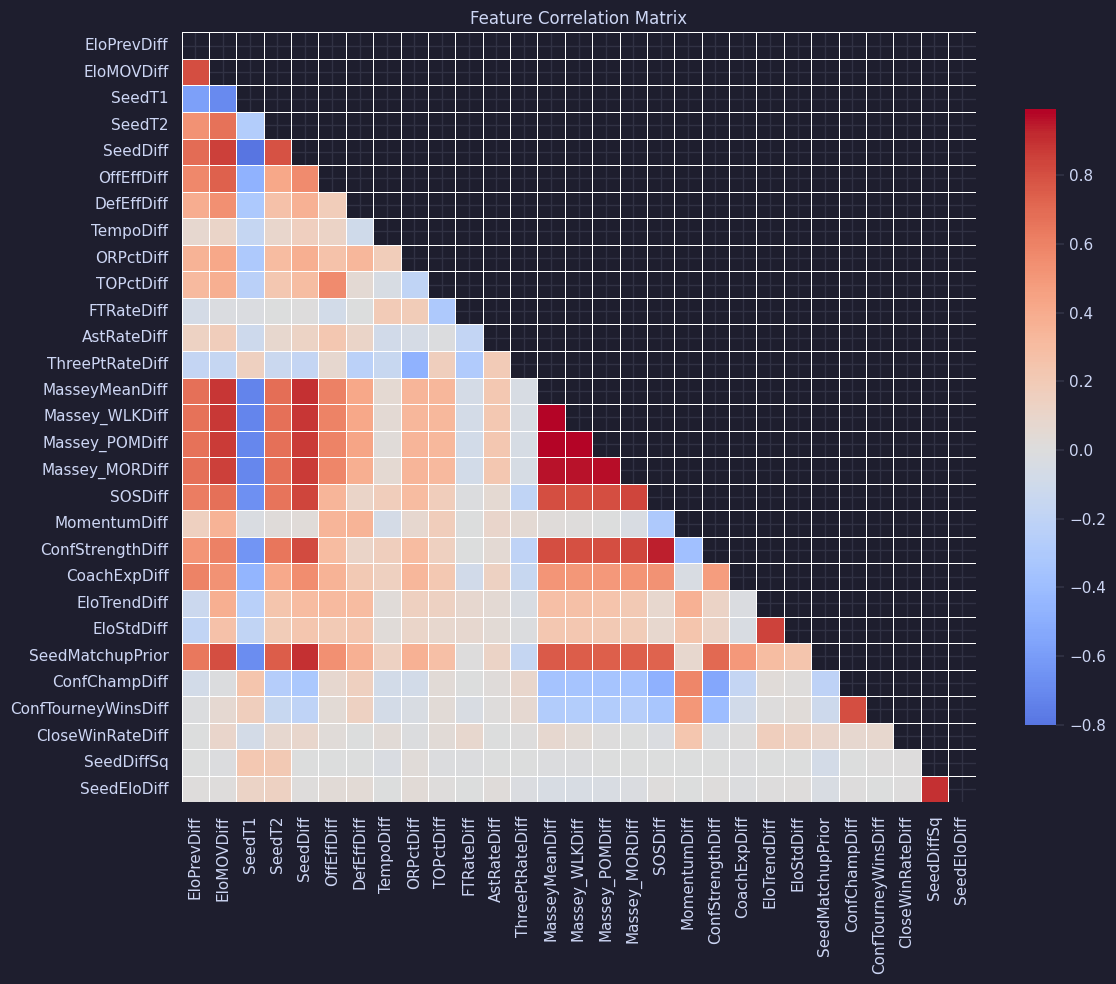

In [22]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [23]:
# Compute training-set medians for NaN imputation
IMPUTE_MEDIANS = X.median().to_dict()

# Per-gender imputation medians
IMPUTE_MEDIANS_M = X[genders.values == "M"].median().to_dict()
IMPUTE_MEDIANS_W = X[genders.values == "W"].median().to_dict()

# Recency weights: decay=0.75 → 2025→1.0, 2024→0.75, 2023→0.56, 2020→0.24
SAMPLE_WEIGHTS = compute_sample_weights(seasons, decay=0.75)

# Explicit anomaly overrides (multiplied on top of decay weight)
_SEASON_OVERRIDES = {
    2021: 0.10,  # COVID bubble -- all games in Indianapolis, no crowds, unreliable signal
}
for _s, _factor in _SEASON_OVERRIDES.items():
    SAMPLE_WEIGHTS[seasons.values == _s] *= _factor

print("Imputation medians ready (combined + per-gender).")
print(f"Sample weight range: [{SAMPLE_WEIGHTS.min():.5f}, {SAMPLE_WEIGHTS.max():.4f}]")

Imputation medians ready (combined + per-gender).
Sample weight range: [0.00178, 1.0000]


## 5b. Feature Selection (Shadow Method) — Per Gender

Fit LightGBM 20× with different seeds on original + shuffled "shadow" copies of each feature.
Keep only features whose mean gain importance consistently beats the best shadow feature.

**Men's**: full feature set including Massey + CoachExp.
**Women's**: reduced feature set (no Massey, no CoachExp — always NaN for women).

In [24]:
import json as _json
from pathlib import Path as _Path

_CACHE = _Path("cache")
_X_PATH  = _CACHE / "X.parquet"
_META_PATH = _CACHE / "meta.json"

# Invalidate cache if it doesn't have hybrid info
_cache_valid = False
if _X_PATH.exists() and _META_PATH.exists():
    _meta = _json.loads(_META_PATH.read_text())
    _cache_valid = "feature_cols_hybrid" in _meta

if _cache_valid:
    X       = pd.read_parquet(_X_PATH)
    y       = pd.Series(_meta["y"],       name="y")
    seasons = pd.Series(_meta["seasons"], name="Season")
    genders = pd.Series(_meta["genders"], name="Gender")
    FEATURE_COLS    = _meta["feature_cols"]
    FEATURE_COLS_M  = _meta["feature_cols_m"]
    FEATURE_COLS_W  = _meta["feature_cols_w"]
    FEATURE_COLS_HYBRID = _meta["feature_cols_hybrid"]
    IMPUTE_MEDIANS  = _meta["impute_medians"]
    IMPUTE_MEDIANS_M = _meta["impute_medians_m"]
    IMPUTE_MEDIANS_W = _meta["impute_medians_w"]
    IMPUTE_MEDIANS_HYBRID = _meta["impute_medians_hybrid"]
    SAMPLE_WEIGHTS  = np.array(_meta["sample_weights"])
    print(f"[cache] Loaded X{X.shape}")
    print(f"  Men's features  ({len(FEATURE_COLS_M)}): {FEATURE_COLS_M}")
    print(f"  Women's features ({len(FEATURE_COLS_W)}): {FEATURE_COLS_W}")
    print(f"  Hybrid features  ({len(FEATURE_COLS_HYBRID)}): {FEATURE_COLS_HYBRID}")

else:
    from lightgbm import LGBMClassifier as _LGBM
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

    def _shadow_select(X_sub, y_sub, force_keep, label):
        """Run shadow feature selection on a subset of data."""
        N_RUNS = 20
        imp_medians = X_sub.median().to_dict()
        X_imp = X_sub.fillna(imp_medians)
        # Drop all-NaN columns
        valid_cols = [c for c in X_imp.columns if X_imp[c].notna().any()]
        X_imp = X_imp[valid_cols]
        orig_cols = list(X_imp.columns)

        importance_orig   = np.zeros(len(orig_cols))
        importance_shadow = np.zeros(len(orig_cols))

        rng = np.random.default_rng(42)
        for run in range(N_RUNS):
            X_shadow = X_imp.copy()
            shadow_cols = [f"shadow_{c}" for c in orig_cols]
            for col, scol in zip(orig_cols, shadow_cols):
                X_shadow[scol] = rng.permutation(X_imp[col].values)

            m = _LGBM(n_estimators=200, max_depth=4, learning_rate=0.05,
                       num_leaves=31, verbose=-1, random_state=run)
            m.fit(X_shadow.values, y_sub.values)

            imp = dict(zip(orig_cols + shadow_cols, m.feature_importances_))
            for i, col in enumerate(orig_cols):
                importance_orig[i]   += imp[col]
                importance_shadow[i] += imp[f"shadow_{col}"]

        importance_orig   /= N_RUNS
        importance_shadow /= N_RUNS

        threshold = importance_shadow.mean()
        selected = [
            col for col, imp in zip(orig_cols, importance_orig)
            if imp > threshold or col in force_keep
        ]
        dropped = [col for col in orig_cols if col not in selected]
        print(f"\n{label} shadow threshold: {threshold:.1f}")
        print(f"  KEPT    ({len(selected)}): {selected}")
        print(f"  DROPPED ({len(dropped)}): {dropped}")
        return selected

    # Men's: include Massey + CoachExp
    m_mask = (genders == "M").values
    FEATURE_COLS_M = _shadow_select(
        X[m_mask], y[m_mask],
        force_keep={"MasseyMeanDiff", "CoachExpDiff", "SeedT1", "SeedT2"},
        label="Men's",
    )

    # Women's: exclude men-only features, simpler set
    w_mask = (genders == "W").values
    _mens_only = {"MasseyMeanDiff", "CoachExpDiff", "Massey_WLKDiff", "Massey_POMDiff", "Massey_MORDiff"}
    w_cols_candidate = [c for c in X.columns if c not in _mens_only]
    FEATURE_COLS_W = _shadow_select(
        X.loc[w_mask, w_cols_candidate], y[w_mask],
        force_keep={"SeedT1", "SeedT2", "SeedDiff"},
        label="Women's",
    )

    # Add GenderM flag for hybrid models
    X["GenderM"] = (genders == "M").astype(int).values

    # Hybrid features = union of M + W + GenderM
    FEATURE_COLS_HYBRID = sorted(set(FEATURE_COLS_M) | set(FEATURE_COLS_W) | {"GenderM"})

    # Combined feature cols = union (for the full X matrix)
    FEATURE_COLS = sorted(set(FEATURE_COLS_M) | set(FEATURE_COLS_W))
    IMPUTE_MEDIANS   = X[FEATURE_COLS].median().to_dict()
    IMPUTE_MEDIANS_M = X.loc[m_mask, FEATURE_COLS_M].median().to_dict()
    IMPUTE_MEDIANS_W = X.loc[w_mask, FEATURE_COLS_W].median().to_dict()
    IMPUTE_MEDIANS_HYBRID = X[FEATURE_COLS_HYBRID].median().to_dict()

    print(f"\nCombined feature union: {len(FEATURE_COLS)} features")
    print(f"Hybrid features: {len(FEATURE_COLS_HYBRID)} features")

    # Save to cache
    _CACHE.mkdir(exist_ok=True)
    X.to_parquet(_X_PATH)
    _META_PATH.write_text(_json.dumps({
        "y":              y.tolist(),
        "seasons":        seasons.tolist(),
        "genders":        genders.tolist(),
        "feature_cols":   FEATURE_COLS,
        "feature_cols_m": FEATURE_COLS_M,
        "feature_cols_w": FEATURE_COLS_W,
        "feature_cols_hybrid": FEATURE_COLS_HYBRID,
        "impute_medians":   IMPUTE_MEDIANS,
        "impute_medians_m": IMPUTE_MEDIANS_M,
        "impute_medians_w": IMPUTE_MEDIANS_W,
        "impute_medians_hybrid": IMPUTE_MEDIANS_HYBRID,
        "sample_weights": SAMPLE_WEIGHTS.tolist(),
    }))
    print("[cache] Saved to cache/")


Men's shadow threshold: 36.2
  KEPT    (15): ['EloPrevDiff', 'EloMOVDiff', 'SeedT1', 'SeedT2', 'OffEffDiff', 'DefEffDiff', 'TempoDiff', 'ORPctDiff', 'FTRateDiff', 'AstRateDiff', 'MasseyMeanDiff', 'Massey_POMDiff', 'Massey_MORDiff', 'CoachExpDiff', 'SeedMatchupPrior']
  DROPPED (14): ['SeedDiff', 'TOPctDiff', 'ThreePtRateDiff', 'Massey_WLKDiff', 'SOSDiff', 'MomentumDiff', 'ConfStrengthDiff', 'EloTrendDiff', 'EloStdDiff', 'ConfChampDiff', 'ConfTourneyWinsDiff', 'CloseWinRateDiff', 'SeedDiffSq', 'SeedEloDiff']

Women's shadow threshold: 35.3
  KEPT    (15): ['EloPrevDiff', 'EloMOVDiff', 'SeedT1', 'SeedT2', 'SeedDiff', 'OffEffDiff', 'DefEffDiff', 'FTRateDiff', 'SOSDiff', 'ConfStrengthDiff', 'EloTrendDiff', 'EloStdDiff', 'SeedMatchupPrior', 'CloseWinRateDiff', 'SeedEloDiff']
  DROPPED (9): ['TempoDiff', 'ORPctDiff', 'TOPctDiff', 'AstRateDiff', 'ThreePtRateDiff', 'MomentumDiff', 'ConfChampDiff', 'ConfTourneyWinsDiff', 'SeedDiffSq']

Combined feature union: 22 features
Hybrid features: 23 fe

In [25]:
import gc
# Free shadow selection intermediates
for _v in ['X_imp_full', 'importance_orig', 'importance_shadow']:
    if _v in dir(): del _v
gc.collect()
print('Memory freed after shadow selection')

Memory freed after shadow selection


## 6. Model Training (Hybrid + Gender-Split)

In [26]:
# ── Data splits ──
m_mask = (genders == "M").values
X_m = X.loc[m_mask, FEATURE_COLS_M]
y_m = y[m_mask].reset_index(drop=True)
seasons_m = seasons[m_mask].reset_index(drop=True)
weights_m = SAMPLE_WEIGHTS[m_mask]
X_m_imputed = X_m.fillna(IMPUTE_MEDIANS_M)

w_mask = (genders == "W").values
X_w = X.loc[w_mask, FEATURE_COLS_W].reset_index(drop=True)
y_w = y[w_mask].reset_index(drop=True)
seasons_w = seasons[w_mask].reset_index(drop=True)
weights_w = SAMPLE_WEIGHTS[w_mask]
X_w_imputed = X_w.fillna(IMPUTE_MEDIANS_W)

# Combined data for hybrid models (LR + TabICL)
X_hybrid = X[FEATURE_COLS_HYBRID]
X_hybrid_imputed = X_hybrid.fillna(IMPUTE_MEDIANS_HYBRID)

print(f"Men's:   {X_m.shape[0]:,} games, {X_m.shape[1]} features")
print(f"Women's: {X_w.shape[0]:,} games, {X_w.shape[1]} features")
print(f"Hybrid:  {X_hybrid.shape[0]:,} games, {X_hybrid.shape[1]} features")
print(f"\nHybrid features: {FEATURE_COLS_HYBRID}")

Men's:   1,449 games, 15 features
Women's: 1,402 games, 15 features
Hybrid:  2,851 games, 23 features

Hybrid features: ['AstRateDiff', 'CloseWinRateDiff', 'CoachExpDiff', 'ConfStrengthDiff', 'DefEffDiff', 'EloMOVDiff', 'EloPrevDiff', 'EloStdDiff', 'EloTrendDiff', 'FTRateDiff', 'GenderM', 'MasseyMeanDiff', 'Massey_MORDiff', 'Massey_POMDiff', 'ORPctDiff', 'OffEffDiff', 'SOSDiff', 'SeedDiff', 'SeedEloDiff', 'SeedMatchupPrior', 'SeedT1', 'SeedT2', 'TempoDiff']


In [30]:
# Men's CatBoost (GPU) — lightweight search, CB gets low ensemble weight
cb_params = {
    "iterations": [300, 500],
    "depth": [3, 4],
    "learning_rate": [0.02, 0.05],
    "l2_leaf_reg": [3, 5, 10],
    "min_data_in_leaf": [10, 20],
    "subsample": [0.8, 0.9],
}

cb_model_m = train_or_load(
    "catboost_m",
    CatBoostClassifier,
    X_m_imputed, y_m,
    param_dist=cb_params,
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": 0, "eval_metric": "Logloss", "bootstrap_type": "Bernoulli", "task_type": "GPU"},
    sample_weight=weights_m,
    n_iter=10, cv=5, scoring="neg_brier_score", n_jobs=1,
)

print("\nMen's CatBoost LOSO CV:")
cb_cv_m, cb_oof_m = leave_one_season_out_cv(
    lambda: CatBoostClassifier(**{k: v for k, v in cb_model_m.get_params().items()
                                  if k not in ("nan_value_treatment", "verbose", "task_type", "bootstrap_type")},
                               verbose=0, bootstrap_type="Bernoulli", task_type="GPU"),
    X_m, y_m, seasons_m,
    impute=True,
    sample_weight=weights_m,
    return_preds=True,
)

Best params: {'subsample': 0.8, 'min_data_in_leaf': 20, 'learning_rate': 0.02, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 3}

Men's CatBoost LOSO CV:
  LOSO mean Brier: 0.1893


In [31]:
# ── Hybrid LR (trained on combined men's + women's data) ──
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr_model_hybrid = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
)
lr_model_hybrid.fit(X_hybrid_imputed.values, y.values,
                    logisticregression__sample_weight=SAMPLE_WEIGHTS)
print("Hybrid LR trained.")

# Hybrid LR LOSO CV
lr_oof_hybrid = np.zeros(len(y))
for season in sorted(seasons.unique()):
    tr = (seasons != season).values
    te = (seasons == season).values
    X_tr, X_te = X_hybrid[tr].copy(), X_hybrid[te].copy()
    meds = X_tr.median()
    X_tr, X_te = X_tr.fillna(meds), X_te.fillna(meds)
    m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))
    m.fit(X_tr.values, y[tr].values, logisticregression__sample_weight=SAMPLE_WEIGHTS[tr])
    p = m.predict_proba(X_te.values)[:, 1]
    lr_oof_hybrid[te] = p

# Split hybrid OOF by gender for per-gender evaluation
lr_oof_m = lr_oof_hybrid[m_mask]
lr_oof_w = lr_oof_hybrid[w_mask]
lr_cv_m = {s: brier_score(y_m[seasons_m == s].values, lr_oof_m[(seasons_m == s).values])
           for s in sorted(seasons_m.unique())}
lr_cv_w = {s: brier_score(y_w[seasons_w == s].values, lr_oof_w[(seasons_w == s).values])
           for s in sorted(seasons_w.unique())}
print(f"Hybrid LR — Men's LOSO mean Brier:   {np.mean(list(lr_cv_m.values())):.4f}")
print(f"Hybrid LR — Women's LOSO mean Brier: {np.mean(list(lr_cv_w.values())):.4f}")

# ── Hybrid TabICL (trained on combined data) ──
tabicl_model_hybrid = train_or_load("tabicl_hybrid", TabICLClassifier,
                                     X_hybrid_imputed.values, y.values,
                                     param_dist=None, model_kwargs={"n_estimators": 32})

print("\nHybrid TabICL LOSO CV:")
tabicl_oof_hybrid = np.zeros(len(y))
for season in sorted(seasons.unique()):
    tr = (seasons != season).values
    te = (seasons == season).values
    X_tr, X_te = X_hybrid[tr].copy(), X_hybrid[te].copy()
    meds = X_tr.median()
    X_tr, X_te = X_tr.fillna(meds), X_te.fillna(meds)
    m = TabICLClassifier(n_estimators=32, random_state=RANDOM_STATE)
    m.fit(X_tr.values, y[tr].values)
    p = m.predict_proba(X_te.values)[:, 1]
    tabicl_oof_hybrid[te] = p

tabicl_oof_m = tabicl_oof_hybrid[m_mask]
tabicl_oof_w = tabicl_oof_hybrid[w_mask]
tabicl_cv_m = {s: brier_score(y_m[seasons_m == s].values, tabicl_oof_m[(seasons_m == s).values])
               for s in sorted(seasons_m.unique())}
tabicl_cv_w = {s: brier_score(y_w[seasons_w == s].values, tabicl_oof_w[(seasons_w == s).values])
               for s in sorted(seasons_w.unique())}
print(f"Hybrid TabICL — Men's LOSO mean Brier:   {np.mean(list(tabicl_cv_m.values())):.4f}")
print(f"Hybrid TabICL — Women's LOSO mean Brier: {np.mean(list(tabicl_cv_w.values())):.4f}")

Hybrid LR trained.
Hybrid LR — Men's LOSO mean Brier:   0.1879
Hybrid LR — Women's LOSO mean Brier: 0.1415
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]


Hybrid TabICL LOSO CV:
Hybrid TabICL — Men's LOSO mean Brier:   0.1833
Hybrid TabICL — Women's LOSO mean Brier: 0.1390


In [32]:
# ── Women's gender-specific models (XGBoost + LightGBM) ──
# LR and TabICL come from hybrid training above

# Women's XGBoost
xgb_model_w = train_or_load(
    "xgboost_w",
    XGBClassifier,
    X_w, y_w,
    param_dist={
        "n_estimators": [200, 300, 500],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "min_child_weight": [1, 3, 5],
        "reg_alpha": [0, 0.1, 1.0],
        "reg_lambda": [1.0, 2.0, 5.0],
    },
    random_state=RANDOM_STATE,
    model_kwargs={"eval_metric": "logloss", "verbosity": 0, "device": "cuda"},
    sample_weight=weights_w,
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("Women's XGBoost LOSO CV:")
xgb_cv_w, xgb_oof_w = leave_one_season_out_cv(
    lambda: XGBClassifier(**{k: v for k, v in xgb_model_w.get_params().items() if k != "device"}, device="cuda"),
    X_w, y_w, seasons_w,
    sample_weight=weights_w,
    return_preds=True,
)

# Women's LightGBM
lgbm_model_w = train_or_load(
    "lightgbm_w",
    LGBMClassifier,
    X_w, y_w,
    param_dist={
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "num_leaves": [7, 15, 31],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "min_child_samples": [5, 10, 20],
        "reg_alpha": [0, 0.1, 1.0],
        "reg_lambda": [1.0, 2.0, 5.0],
    },
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": -1},
    sample_weight=weights_w,
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nWomen's LightGBM LOSO CV:")
lgbm_cv_w, lgbm_oof_w = leave_one_season_out_cv(
    lambda: LGBMClassifier(**{k: v for k, v in lgbm_model_w.get_params().items() if k != "device"}),
    X_w, y_w, seasons_w,
    sample_weight=weights_w,
    return_preds=True,
)

Best params: {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Women's XGBoost LOSO CV:
  LOSO mean Brier: 0.1446
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Women's LightGBM LOSO CV:
  LOSO mean Brier: 0.1432


In [33]:
# CV summary: Men's (hybrid LR + CatBoost + hybrid TabICL)
print("=" * 60)
print("MEN'S CV RESULTS")
print("=" * 60)
cv_results_m = {
    "LR (hybrid)":      lr_cv_m,
    "CatBoost":         cb_cv_m,
    "TabICL (hybrid)":  tabicl_cv_m,
}
cv_df_m = pd.DataFrame(cv_results_m).sort_index()
cv_df_m.loc['Mean (all)']   = cv_df_m.mean()
recent_m = [s for s in cv_results_m['CatBoost'] if s >= 2022]
cv_df_m.loc['Mean (22-25)'] = cv_df_m.loc[recent_m].mean()
print(cv_df_m.round(4).to_string())

print("\n")
print("=" * 60)
print("WOMEN'S CV RESULTS")
print("=" * 60)
cv_results_w = {
    "LR (hybrid)":      lr_cv_w,
    "XGBoost":          xgb_cv_w,
    "LightGBM":         lgbm_cv_w,
    "TabICL (hybrid)":  tabicl_cv_w,
}
cv_df_w = pd.DataFrame(cv_results_w).sort_index()
cv_df_w.loc['Mean (all)']   = cv_df_w.mean()
recent_w = [s for s in cv_results_w['XGBoost'] if s >= 2022]
cv_df_w.loc['Mean (22-25)'] = cv_df_w.loc[recent_w].mean()
print(cv_df_w.round(4).to_string())

MEN'S CV RESULTS
              LR (hybrid)  CatBoost  TabICL (hybrid)
2003               0.1964    0.1872           0.1842
2004               0.1665    0.1848           0.1740
2005               0.1838    0.1825           0.1772
2006               0.1970    0.1941           0.1933
2007               0.1434    0.1438           0.1424
2008               0.1564    0.1427           0.1471
2009               0.1734    0.1841           0.1711
2010               0.2001    0.1927           0.1924
2011               0.2121    0.1987           0.2072
2012               0.1870    0.2106           0.1935
2013               0.2239    0.2181           0.2173
2014               0.1866    0.1889           0.1886
2015               0.1639    0.1684           0.1731
2016               0.1951    0.1820           0.1850
2017               0.1977    0.2044           0.1812
2018               0.2063    0.1909           0.1960
2019               0.1586    0.1763           0.1595
2021               0.2244    

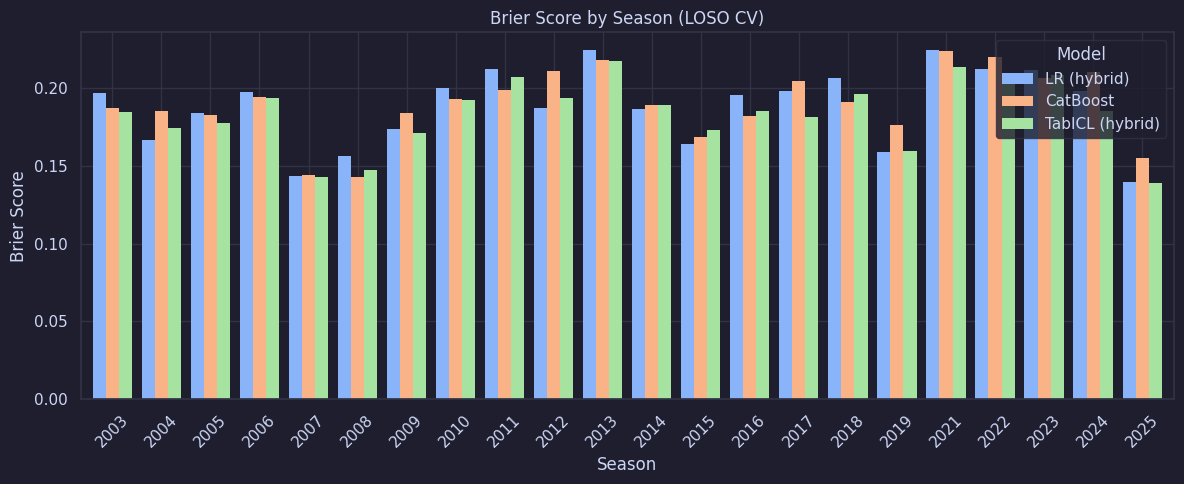

In [34]:
plot_brier_by_season(cv_results_m, C.cycle)
plt.show()

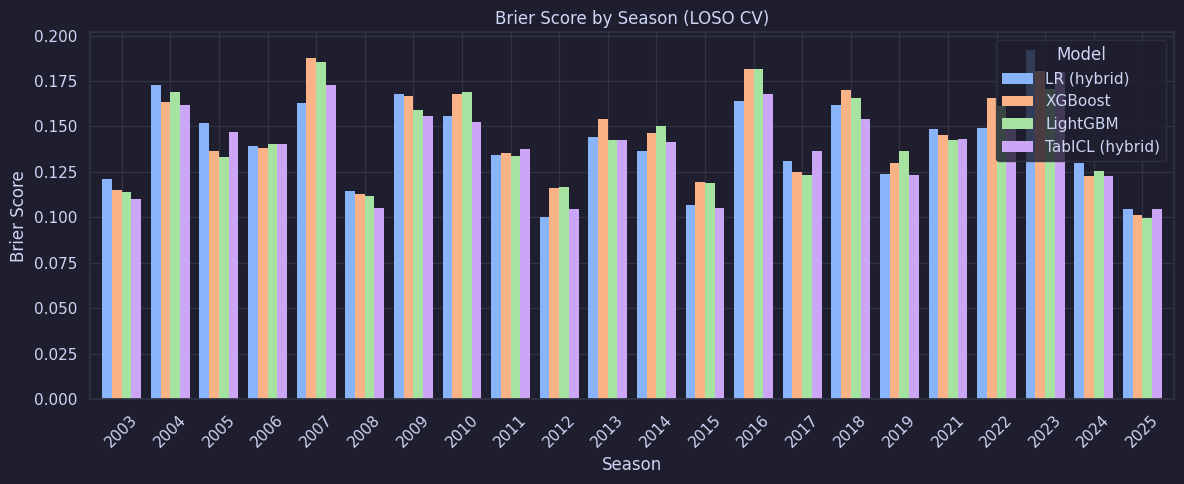

In [35]:
plot_brier_by_season(cv_results_w, C.cycle)
plt.show()

## 7. Ensemble

In [36]:
from scipy.optimize import minimize

def optimize_weights(oofs, y_arr, seasons_arr, model_names, label=""):
    """Optimize ensemble weights on recent OOF predictions."""
    recent_mask = np.array([s >= 2022 for s in seasons_arr])
    n = len(model_names)
    def neg_brier(w):
        w = np.abs(w) / np.abs(w).sum()
        preds = oofs[recent_mask] @ w
        return np.mean((preds - y_arr[recent_mask]) ** 2)
    res = minimize(neg_brier, x0=[1.0/n]*n,
                   method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 10000})
    w_opt = np.abs(res.x) / np.abs(res.x).sum()
    weights = dict(zip(model_names, w_opt))
    print(f"{label} ensemble weights (22-25 OOF):")
    for name, w in sorted(weights.items(), key=lambda x: -x[1]):
        print(f"  {name:20s}  weight={w:.3f}")
    return weights

# Men's ensemble (3 models: hybrid LR + CatBoost + hybrid TabICL)
oofs_m = np.column_stack([lr_oof_m, cb_oof_m, tabicl_oof_m])
model_names_m = ['LR', 'CatBoost', 'TabICL']
ens_weights_m = optimize_weights(oofs_m, y_m.values, seasons_m.values, model_names_m, "Men's")

print()

# Women's ensemble (4 models: hybrid LR + XGBoost + LightGBM + hybrid TabICL)
oofs_w = np.column_stack([lr_oof_w, xgb_oof_w, lgbm_oof_w, tabicl_oof_w])
model_names_w = ['LR', 'XGBoost', 'LightGBM', 'TabICL']
ens_weights_w = optimize_weights(oofs_w, y_w.values, seasons_w.values, model_names_w, "Women's")

Men's ensemble weights (22-25 OOF):
  TabICL                weight=1.000
  LR                    weight=0.000
  CatBoost              weight=0.000

Women's ensemble weights (22-25 OOF):
  TabICL                weight=0.530
  LightGBM              weight=0.470
  XGBoost               weight=0.000
  LR                    weight=0.000


In [37]:
# Per-gender ensemble LOSO evaluation
def compute_ensemble_cv(oofs, weights_dict, model_names, y_arr, seasons_arr):
    w = np.array([weights_dict[n] for n in model_names])
    oof_ens = oofs @ w
    cv = {}
    for season in sorted(pd.Series(seasons_arr).unique()):
        mask = seasons_arr == season
        if mask.sum() > 0:
            cv[season] = brier_score(y_arr[mask], oof_ens[mask])
    return cv, oof_ens

ens_cv_m, oof_ens_m = compute_ensemble_cv(oofs_m, ens_weights_m, model_names_m, y_m.values, seasons_m.values)
ens_cv_w, oof_ens_w = compute_ensemble_cv(oofs_w, ens_weights_w, model_names_w, y_w.values, seasons_w.values)

print("MEN'S Ensemble LOSO:")
for s, b in sorted(ens_cv_m.items()):
    print(f"  {s}: {b:.4f}")
print(f"  Mean (all):   {np.mean(list(ens_cv_m.values())):.4f}")
print(f"  Mean (22-25): {np.mean([v for s, v in ens_cv_m.items() if s >= 2022]):.4f}")

print("\nWOMEN'S Ensemble LOSO:")
for s, b in sorted(ens_cv_w.items()):
    print(f"  {s}: {b:.4f}")
print(f"  Mean (all):   {np.mean(list(ens_cv_w.values())):.4f}")
print(f"  Mean (22-25): {np.mean([v for s, v in ens_cv_w.items() if s >= 2022]):.4f}")

MEN'S Ensemble LOSO:
  2003: 0.1842
  2004: 0.1740
  2005: 0.1772
  2006: 0.1933
  2007: 0.1424
  2008: 0.1471
  2009: 0.1711
  2010: 0.1924
  2011: 0.2072
  2012: 0.1935
  2013: 0.2173
  2014: 0.1886
  2015: 0.1731
  2016: 0.1850
  2017: 0.1812
  2018: 0.1960
  2019: 0.1595
  2021: 0.2134
  2022: 0.2040
  2023: 0.2085
  2024: 0.1854
  2025: 0.1389
  Mean (all):   0.1833
  Mean (22-25): 0.1842

WOMEN'S Ensemble LOSO:
  2003: 0.1105
  2004: 0.1635
  2005: 0.1387
  2006: 0.1386
  2007: 0.1768
  2008: 0.1068
  2009: 0.1558
  2010: 0.1586
  2011: 0.1342
  2012: 0.1087
  2013: 0.1409
  2014: 0.1443
  2015: 0.1096
  2016: 0.1725
  2017: 0.1287
  2018: 0.1584
  2019: 0.1275
  2021: 0.1415
  2022: 0.1517
  2023: 0.1732
  2024: 0.1211
  2025: 0.1009
  Mean (all):   0.1392
  Mean (22-25): 0.1367


In [38]:
# Combined pooled Brier (2022-2025) — the metric that matters
oof_combined = np.concatenate([oof_ens_m, oof_ens_w])
y_combined = np.concatenate([y_m.values, y_w.values])
seasons_combined = np.concatenate([seasons_m.values, seasons_w.values])

mask_2225 = seasons_combined >= 2022
pooled_brier = brier_score(y_combined[mask_2225], oof_combined[mask_2225])
n_games = mask_2225.sum()

print(f"COMBINED Pooled Brier (2022-2025): {pooled_brier:.5f}  ({n_games} games)")
print(f"  vs. old combined model:          0.16143")
print(f"  Improvement:                     {0.16143 - pooled_brier:+.5f}")

# Per-gender breakdown
mask_m_2225 = seasons_m.values >= 2022
mask_w_2225 = seasons_w.values >= 2022
print(f"\n  Men's pooled (22-25):   {brier_score(y_m.values[mask_m_2225], oof_ens_m[mask_m_2225]):.5f}  ({mask_m_2225.sum()} games)")
print(f"  Women's pooled (22-25): {brier_score(y_w.values[mask_w_2225], oof_ens_w[mask_w_2225]):.5f}  ({mask_w_2225.sum()} games)")

COMBINED Pooled Brier (2022-2025): 0.16046  (536 games)
  vs. old combined model:          0.16143
  Improvement:                     +0.00097

  Men's pooled (22-25):   0.18420  (268 games)
  Women's pooled (22-25): 0.13673  (268 games)


## 7b. Isotonic Calibration

Fit isotonic regression on OOF ensemble predictions (already out-of-sample) to fix miscalibration.
Tree models tend to cluster predictions around 0.5; calibration stretches them toward 0/1 where warranted.
Separate calibrators per gender since men's and women's have different calibration curves.

In [39]:
from sklearn.isotonic import IsotonicRegression

# Fit per-gender isotonic calibrators on OOF ensemble predictions
calibrator_m = IsotonicRegression(out_of_bounds="clip", y_min=0.01, y_max=0.99)
calibrator_m.fit(oof_ens_m, y_m.values)

calibrator_w = IsotonicRegression(out_of_bounds="clip", y_min=0.01, y_max=0.99)
calibrator_w.fit(oof_ens_w, y_w.values)

# Apply calibration to OOF predictions to measure improvement
oof_cal_m = calibrator_m.predict(oof_ens_m)
oof_cal_w = calibrator_w.predict(oof_ens_w)

# Compare before/after calibration (on 2022-2025)
mask_m_2225 = seasons_m.values >= 2022
mask_w_2225 = seasons_w.values >= 2022

brier_m_before = brier_score(y_m.values[mask_m_2225], oof_ens_m[mask_m_2225])
brier_m_after = brier_score(y_m.values[mask_m_2225], oof_cal_m[mask_m_2225])
brier_w_before = brier_score(y_w.values[mask_w_2225], oof_ens_w[mask_w_2225])
brier_w_after = brier_score(y_w.values[mask_w_2225], oof_cal_w[mask_w_2225])

# Combined
oof_cal_combined = np.concatenate([oof_cal_m, oof_cal_w])
mask_2225 = np.concatenate([mask_m_2225, mask_w_2225])
y_all = np.concatenate([y_m.values, y_w.values])
pooled_before = brier_score(y_all[mask_2225], np.concatenate([oof_ens_m, oof_ens_w])[mask_2225])
pooled_after = brier_score(y_all[mask_2225], oof_cal_combined[mask_2225])

print("Isotonic Calibration (2022-2025 OOF):")
print(f"  Men's:   {brier_m_before:.5f} → {brier_m_after:.5f}  ({brier_m_before - brier_m_after:+.5f})")
print(f"  Women's: {brier_w_before:.5f} → {brier_w_after:.5f}  ({brier_w_before - brier_w_after:+.5f})")
print(f"  Combined:{pooled_before:.5f} → {pooled_after:.5f}  ({pooled_before - pooled_after:+.5f})")
print(f"\n⚠️  Note: calibration on OOF is slightly optimistic (fitted on same data).")
print(f"  True improvement will be smaller but directionally correct.")

Isotonic Calibration (2022-2025 OOF):
  Men's:   0.18420 → 0.18305  (+0.00115)
  Women's: 0.13673 → 0.13711  (-0.00038)
  Combined:0.16046 → 0.16008  (+0.00038)

⚠️  Note: calibration on OOF is slightly optimistic (fitted on same data).
  True improvement will be smaller but directionally correct.


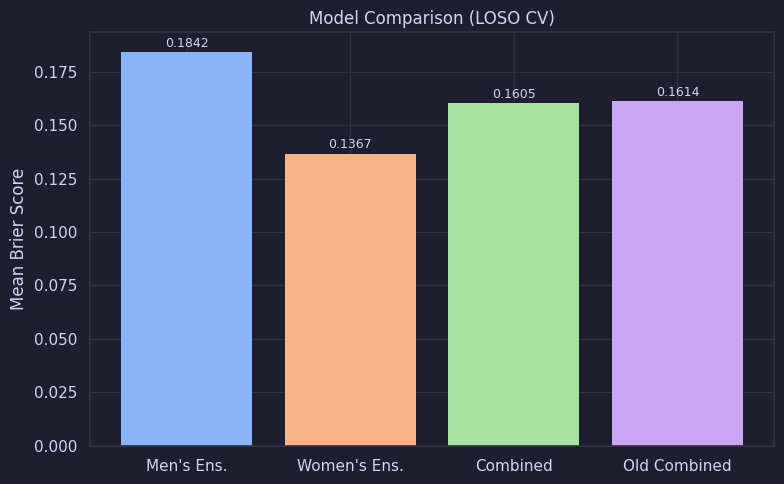

In [40]:
# Model comparison: per-gender ensemble Brier (22-25)
mask_m_recent = seasons_m.values >= 2022
mask_w_recent = seasons_w.values >= 2022
mean_briers = {
    "Men's Ens.": brier_score(y_m.values[mask_m_recent], oof_ens_m[mask_m_recent]),
    "Women's Ens.": brier_score(y_w.values[mask_w_recent], oof_ens_w[mask_w_recent]),
    "Combined": pooled_brier,
    "Old Combined": 0.16143,
}
plot_model_comparison(mean_briers, C.cycle)
plt.show()

## 8. Submission Generation

In [41]:
# Gender-specific models (predict on their gender's rows only)
models_m_specific = {
    "CatBoost": cb_model_m,
}
models_w_specific = {
    "XGBoost":  xgb_model_w,
    "LightGBM": lgbm_model_w,
}

# Hybrid models (predict on all rows using FEATURE_COLS_HYBRID)
hybrid_models = {
    "LR":     lr_model_hybrid,
    "TabICL": tabicl_model_hybrid,
}

In [ ]:
# Stage 1: seasons 2022–2025
extra_feats = dict(seed_prior=seed_prior, conf_champ=conf_champ,
                   conf_tourney_wins=conf_tw, close_game_wr=close_game_wr)

X_all = build_features_vectorized(
    data["sample_sub"], elo_prev, elo_curr, seed_map, stats_df, massey_df,
    elo_stats=elo_stats, sos=sos, momentum=momentum,
    conf_strength=conf_strength, coach_exp=coach_exp, **extra_feats,
)

# Add GenderM flag for hybrid models
team1 = data["sample_sub"]["ID"].str.split("_").str[1].astype(int)
is_mens = (team1 < 2000).values
X_all["GenderM"] = is_mens.astype(int)

# Hybrid model predictions (all rows)
X_h = X_all[FEATURE_COLS_HYBRID].fillna(IMPUTE_MEDIANS_HYBRID)
hybrid_preds = {}
for name, model in hybrid_models.items():
    hybrid_preds[name] = model.predict_proba(X_h.values)[:, 1]
    print(f"  Hybrid {name}: mean={hybrid_preds[name].mean():.4f}, std={hybrid_preds[name].std():.4f}")

# Gender-specific model predictions
preds = np.zeros(len(X_all))

# Men's ensemble
X_m_sub = X_all.loc[is_mens, FEATURE_COLS_M].fillna(IMPUTE_MEDIANS_M)
gender_preds_m = np.zeros(is_mens.sum())
for name, model in models_m_specific.items():
    w = ens_weights_m[name]
    p = model.predict_proba(X_m_sub.values)[:, 1]
    gender_preds_m += w * p
    print(f"  Men's {name}: mean={p.mean():.4f}, std={p.std():.4f}, weight={w:.3f}")
for name in hybrid_models:
    w = ens_weights_m[name]
    gender_preds_m += w * hybrid_preds[name][is_mens]
    print(f"  Men's {name} (hybrid): weight={w:.3f}")
preds[is_mens] = gender_preds_m

# Women's ensemble
X_w_sub = X_all.loc[~is_mens, FEATURE_COLS_W].fillna(IMPUTE_MEDIANS_W)
gender_preds_w = np.zeros((~is_mens).sum())
for name, model in models_w_specific.items():
    w = ens_weights_w[name]
    p = model.predict_proba(X_w_sub)[:, 1]
    gender_preds_w += w * p
    print(f"  Women's {name}: mean={p.mean():.4f}, std={p.std():.4f}, weight={w:.3f}")
for name in hybrid_models:
    w = ens_weights_w[name]
    gender_preds_w += w * hybrid_preds[name][~is_mens]
    print(f"  Women's {name} (hybrid): weight={w:.3f}")
preds[~is_mens] = gender_preds_w

# Apply isotonic calibration per gender
preds[is_mens] = calibrator_m.predict(preds[is_mens])
preds[~is_mens] = calibrator_w.predict(preds[~is_mens])
preds = np.clip(preds, 0.01, 0.99)

sub1 = data["sample_sub"][["ID"]].copy()
sub1["Pred"] = preds
sub1.to_csv("submission_stage1.csv", index=False)
print(f"\nStage 1: {sub1.shape[0]:,} rows (isotonic-calibrated)")
print(f"Range : [{sub1['Pred'].min():.4f}, {sub1['Pred'].max():.4f}]")
print(f"Mean  : {sub1['Pred'].mean():.4f}  Std: {sub1['Pred'].std():.4f}")
sub1.head()

  Hybrid LR: mean=0.5092, std=0.3002


In [ ]:
# Stage 2: season 2026
X_all2 = build_features_vectorized(
    data["sample_sub2"], elo_prev, elo_curr, seed_map, stats_df, massey_df,
    elo_stats=elo_stats, sos=sos, momentum=momentum,
    conf_strength=conf_strength, coach_exp=coach_exp, **extra_feats,
)

team1_2 = data["sample_sub2"]["ID"].str.split("_").str[1].astype(int)
is_mens2 = (team1_2 < 2000).values
X_all2["GenderM"] = is_mens2.astype(int)

# Hybrid model predictions (all rows)
X_h2 = X_all2[FEATURE_COLS_HYBRID].fillna(IMPUTE_MEDIANS_HYBRID)
hybrid_preds2 = {}
for name, model in hybrid_models.items():
    hybrid_preds2[name] = model.predict_proba(X_h2.values)[:, 1]

# Gender-specific model predictions
preds2 = np.zeros(len(X_all2))

# Men's
X_m_sub2 = X_all2.loc[is_mens2, FEATURE_COLS_M].fillna(IMPUTE_MEDIANS_M)
gender_preds_m2 = np.zeros(is_mens2.sum())
for name, model in models_m_specific.items():
    gender_preds_m2 += ens_weights_m[name] * model.predict_proba(X_m_sub2.values)[:, 1]
for name in hybrid_models:
    gender_preds_m2 += ens_weights_m[name] * hybrid_preds2[name][is_mens2]
preds2[is_mens2] = gender_preds_m2

# Women's
X_w_sub2 = X_all2.loc[~is_mens2, FEATURE_COLS_W].fillna(IMPUTE_MEDIANS_W)
gender_preds_w2 = np.zeros((~is_mens2).sum())
for name, model in models_w_specific.items():
    gender_preds_w2 += ens_weights_w[name] * model.predict_proba(X_w_sub2)[:, 1]
for name in hybrid_models:
    gender_preds_w2 += ens_weights_w[name] * hybrid_preds2[name][~is_mens2]
preds2[~is_mens2] = gender_preds_w2

# Isotonic calibration
preds2[is_mens2] = calibrator_m.predict(preds2[is_mens2])
preds2[~is_mens2] = calibrator_w.predict(preds2[~is_mens2])
preds2 = np.clip(preds2, 0.01, 0.99)

sub2 = data["sample_sub2"][["ID"]].copy()
sub2["Pred"] = preds2
sub2.to_csv("submission_stage2.csv", index=False)
print(f"\nStage 2: {sub2.shape[0]:,} rows (isotonic-calibrated)")
print(f"Range : [{sub2['Pred'].min():.4f}, {sub2['Pred'].max():.4f}]")
print(f"Mean  : {sub2['Pred'].mean():.4f}  Std: {sub2['Pred'].std():.4f}")
sub2.head()

## 9. Validation Visualizations

In [ ]:
plot_prediction_distribution(sub1["Pred"], color=C.blue)
plt.title("Stage 1: Prediction Distribution")
plt.show()

In [ ]:
# Feature importance: Men's CatBoost + Women's XGBoost and LightGBM
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_feature_importance(cb_model_m,   FEATURE_COLS_M, top_n=15, color=C.green, ax=axes[0])
plot_feature_importance(xgb_model_w,  FEATURE_COLS_W, top_n=15, color=C.blue,  ax=axes[1])
plot_feature_importance(lgbm_model_w, FEATURE_COLS_W, top_n=15, color=C.pink,  ax=axes[2])
axes[0].set_title("Men's CatBoost Feature Importance")
axes[1].set_title("Women's XGBoost Feature Importance")
axes[2].set_title("Women's LightGBM Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Calibration curve on men's LOSO OOF ensemble predictions
plot_calibration_curve(y_m.values, oof_ens_m, color=C.blue)
plt.title("Men's Ensemble Calibration (LOSO out-of-fold)")
plt.show()

plot_calibration_curve(y_w.values, oof_ens_w, color=C.pink)
plt.title("Women's Ensemble Calibration (LOSO out-of-fold)")
plt.show()

In [ ]:
# Men's vs Women's prediction distributions (Stage 1)
ids_parsed = sub1["ID"].str.split("_", expand=True).astype(int)
is_mens = ids_parsed[1] < 2000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (mask, title, color) in zip(axes, [
    (is_mens,  "Men's",   C.blue),
    (~is_mens, "Women's", C.pink),
]):
    preds_sub = sub1.loc[mask.values, "Pred"]
    ax.hist(preds_sub, bins=50, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(0.5, color=C.red, linestyle="--", alpha=0.6)
    ax.set_xlabel("P(Team1 wins)")
    ax.set_title(f"{title} ({len(preds_sub):,} matchups)")
axes[0].set_ylabel("Count")
plt.suptitle("Stage 1: Prediction Distribution by Gender")
plt.tight_layout()
plt.show()

In [ ]:
# Sanity check: seed-based predictions for 2024
check_season = 2024
check_sub = sub1[sub1["ID"].str.startswith(f"{check_season}_")].copy()
check_ids = check_sub["ID"].str.split("_", expand=True).astype(int)
check_ids.columns = ["Season", "T1", "T2"]
check_ids["Seed1"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T1"])), axis=1)
check_ids["Seed2"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T2"])), axis=1)
check_ids["Pred"]  = check_sub["Pred"].values

seeded = check_ids.dropna(subset=["Seed1", "Seed2"])
print(f"Seeded matchups in {check_season}: {len(seeded):,}")

vs1_16 = seeded[(seeded["Seed1"] == 1) & (seeded["Seed2"] == 16)]
print(f"\n1 vs 16 seed predictions (expect >0.5 for Team1):")
print(vs1_16[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

vs8_9  = seeded[(seeded["Seed1"] == 8) & (seeded["Seed2"] == 9)]
print(f"\n8 vs 9 seed predictions (expect ~0.5):")
print(vs8_9[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

In [ ]:
# stage_1 = pd.read_csv("../working/submission_stage1.csv")
stage_2 = pd.read_csv("../working/submission_stage2.csv")
stage_2.to_csv("submission.csv", index=False)
print(f"Wrote {len(stage_2)} rows to submission.csv")